In [33]:
import torch
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback

In [2]:
dataset_route = Path("../../dataset/Text Dataset/sentiment_analysis_dataset.csv")

df = pd.read_csv(dataset_route)

df

,user,text,date,emotion,sentiment
0,@erreborda,termine bien abrumado después de hoy,"Jan 6, 2024 · 2:53 AM UTC",overwhelmed,scared
1,@shpiderduck,me siento abrumado,"Jan 6, 2024 · 2:35 AM UTC",overwhelmed,scared
2,@Alex_R_art,Me siento un poco abrumado por la cantidad de ...,"Jan 6, 2024 · 12:20 AM UTC",overwhelmed,scared
3,@anggelinaa97,Salvador la única persona que no la ha abrumad...,"Jan 5, 2024 · 10:38 PM UTC",overwhelmed,scared
4,@diegoreyesvqz,Denme un helado o algo que ando full abrumado.,"Jan 5, 2024 · 8:38 PM UTC",overwhelmed,scared
...,...,...,...,...,...
2585,@lavivianaleyva,No podemos vivir con miedo: ¡Manejen borrach...,"Jan 6, 2024 · 3:08 AM UTC",daring,joyful
2586,@Carmeen_Alicia,"La vida es un constante, SIN MIEDO AL ÉXITO 💅🏼","Jan 6, 2024 · 3:07 AM UTC",daring,joyful
2587,@homicidios_,Esquizofrenia = mente dividida: Miedo a las re...,"Jan 6, 2024 · 2:59 AM UTC",daring,joyful
2588,@brigethcoba,"""Lo que más miedo me da, es ver cómo desaparec...","Jan 6, 2024 · 2:55 AM UTC",daring,joyful


In [3]:
df["emotion"].unique()

<StringArray>
['overwhelmed', 'embarrassed',     'jealous',   'irritated',  'frustrated',
     'distant',      'stupid',    'isolated',      'sleepy',  'responsive',
     'relaxed',      'loving',    'thankful',      'secure',   'confident',
  'successful',   'surprised',     'playful',  'optimistic',      'daring']
Length: 20, dtype: str

In [4]:
df["sentiment"].unique()

<StringArray>
['scared', 'mad', 'sad', 'peaceful', 'powerful', 'joyful']
Length: 6, dtype: str

In [5]:
new_df = df[["text", "sentiment"]]
new_df

,text,sentiment
0,termine bien abrumado después de hoy,scared
1,me siento abrumado,scared
2,Me siento un poco abrumado por la cantidad de ...,scared
3,Salvador la única persona que no la ha abrumad...,scared
4,Denme un helado o algo que ando full abrumado.,scared
...,...,...
2585,No podemos vivir con miedo: ¡Manejen borrach...,joyful
2586,"La vida es un constante, SIN MIEDO AL ÉXITO 💅🏼",joyful
2587,Esquizofrenia = mente dividida: Miedo a las re...,joyful
2588,"""Lo que más miedo me da, es ver cómo desaparec...",joyful


In [6]:
sentiments = new_df["sentiment"].to_list()
label_sentiment = sorted(list(set(sentiments)))
label_sentiment

['joyful', 'mad', 'peaceful', 'powerful', 'sad', 'scared']

In [7]:
label2id = dict((c, i) for i, c in enumerate(label_sentiment))
id2label = dict((i, c) for i, c in enumerate(label_sentiment))

In [8]:
label2id

{'joyful': 0, 'mad': 1, 'peaceful': 2, 'powerful': 3, 'sad': 4, 'scared': 5}

In [9]:
id2label

{0: 'joyful', 1: 'mad', 2: 'peaceful', 3: 'powerful', 4: 'sad', 5: 'scared'}

In [10]:
indexed_labels = np.array([label2id[label] for label in df["sentiment"]])
indexed_labels

array([5, 5, 5, ..., 0, 0, 0], shape=(2590,))

In [11]:
np.unique(indexed_labels)

array([0, 1, 2, 3, 4, 5])

In [12]:
list_text = new_df["text"].astype(str).to_numpy()
list_text

array(['termine bien abrumado después de hoy', 'me siento abrumado',
       'Me siento un poco abrumado por la cantidad de cosas que quiero dibujar, ver, jugar y leer. Odio esta sensación xdddd',
       ...,
       'Esquizofrenia = mente dividida: Miedo a las realidades paralelas que se le presentan. Sin miedo deben aceptar el llamado de dios y abrir las puertas al cielo',
       '"Lo que más miedo me da, es ver cómo desapareces de este mundo, es a lo que más temo, un mundo sin ti…"',
       'Saltando de apoco ala pile sin agua xd sin miedo relajado'],
      shape=(2590,), dtype=object)

In [13]:
train_features, val_features, train_labels, val_labels = train_test_split(list_text, indexed_labels, test_size=0.2, random_state=42, shuffle=True, stratify=indexed_labels)

In [14]:
print(train_features)
print()
print(val_features)

['Ya voy hacer un apartado de dinero exclusivo para armar un equipo de audio de alta fidelidad.'
 'Me sorprende la cantidad de pornx animado que hay osea a quien le puede calentar eso????'
 'Toda la tarde haciendo la Fila Virtual para comprar las entradas de Flor y cuando llegaba ya estaba todo agitado 🥺😭😭😭'
 ...
 'Carlos Saúl Menem estimaba que dolarizar duraría de 6 a 10 años. Meses duro luego y vino el pacto de olivos. Está generación libertaria lo va a hacer más ágil. Dejen de dimar zurdos y comiencen a invertir. VIVA LA LIBERTAD, CARAJOOOO. confío mucho en nuestro sr, presidente Milei'
 'Metas para este 2024 (terminos de gd)  - Esta vez si alcanzar los 50 extremes (espero) - Completar el reto de los 1000 demons en un mes - Desbloquear todos los cofres/iconos de la 2.2 - Llegar a ser algo reconocido masomenos - Maybe  mi ultimo new Hardest en el juego'
 'No confío en los dentistas que hacen resinas-restauraciones sin aislado absolutooo']

['Increíble,Juan Manuel Santos,salvó de un 

In [15]:
print(train_labels)
print()
print(val_labels)

[4 0 1 ... 2 2 4]

[2 4 3 4 1 0 1 4 1 5 3 2 0 2 4 0 0 2 2 5 1 4 0 0 1 5 4 2 2 2 3 5 2 4 1 4 3
 5 2 2 1 0 2 2 0 4 2 1 1 2 1 1 0 3 0 1 1 0 1 5 1 2 3 2 2 1 1 3 2 1 2 3 5 1
 2 2 3 0 0 4 2 2 5 3 3 0 2 2 2 2 5 2 3 1 2 1 5 1 2 3 2 1 0 3 2 5 5 5 1 1 2
 1 1 1 0 2 2 1 1 3 5 3 0 0 4 2 0 1 0 5 2 1 4 1 4 2 5 3 2 3 2 2 1 0 0 3 0 2
 1 3 5 3 0 3 5 4 1 0 2 1 4 3 4 3 3 2 2 2 1 2 2 1 1 3 2 0 5 2 4 2 3 3 4 1 2
 0 2 5 4 4 4 3 3 5 0 5 4 5 3 1 5 4 2 2 1 0 3 4 3 2 3 2 1 2 1 1 0 5 5 2 5 4
 3 3 4 3 2 4 5 1 1 4 2 4 5 1 2 2 2 3 0 1 0 1 2 1 0 3 0 2 3 2 1 2 1 0 5 1 2
 5 3 1 2 2 0 1 3 2 5 2 3 2 1 3 0 1 3 4 0 4 1 0 3 4 0 4 0 5 0 2 3 2 4 5 2 3
 1 3 1 3 1 2 0 2 4 3 2 2 0 1 1 0 2 4 2 3 3 3 2 4 5 1 3 5 3 1 2 3 2 3 2 2 1
 4 1 2 2 4 2 0 0 4 3 1 1 3 1 5 3 4 0 1 1 5 4 0 2 3 5 2 3 0 1 1 2 1 1 4 2 0
 1 2 4 5 0 4 3 1 1 1 2 2 2 5 5 2 2 3 0 3 4 4 3 0 4 1 2 1 3 2 5 0 1 5 2 4 2
 2 0 4 4 1 1 2 3 0 2 1 0 3 3 2 4 0 4 1 1 4 3 2 0 5 1 4 4 1 1 0 3 0 5 0 0 3
 1 1 3 2 2 0 3 4 2 5 2 2 4 3 4 1 4 4 1 1 5 2 4 5 4 5 5 4 2 3 2 2 4 1 3 1 3
 3 4 4

In [16]:
unique_t, counts_t = np.unique(train_labels, return_counts=True)
num_to_string_t = np.array([id2label[label] for label in unique_t])

print("Number of classes Train")
for label_string, count in zip(num_to_string_t, counts_t):
    print(f"Class {label_string}: {count}")

Number of classes Train
Class joyful: 280
Class mad: 424
Class peaceful: 528
Class powerful: 336
Class sad: 288
Class scared: 216


In [17]:
unique_v, counts_v = np.unique(val_labels, return_counts=True)
num_to_string_v = np.array([id2label[label] for label in unique_v])

print("Number of classes Val")
for label_string, count in zip(num_to_string_v, counts_v):
    print(f"Class {label_string}: {count}")

Number of classes Val
Class joyful: 70
Class mad: 106
Class peaceful: 132
Class powerful: 84
Class sad: 72
Class scared: 54


In [18]:
model_name = "pysentimiento/robertuito-base-uncased"
max_length = 128
tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=True)

In [19]:
train_encodings = tokenizer(train_features.tolist(), truncation=True, padding=True, max_length=max_length)
val_encodings = tokenizer(val_features.tolist(), truncation=True, padding=True, max_length=max_length)

In [20]:
class OurTorchDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [21]:
train_dataset = OurTorchDataset(train_encodings, train_labels)
val_dataset = OurTorchDataset(val_encodings, val_labels)

In [22]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(axis=1)
    acc = accuracy_score(labels, preds)
    return{'accuracy': acc,}

In [23]:
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=6).to("cuda")

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 8709.03it/s]
[transformers] RobertaForSequenceClassification LOAD REPORT from: pysentimiento/robertuito-base-uncased
Key                        | Status     | 
---------------------------+------------+-
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [24]:
route_model = Path("../../model/Text Model")

training_args = TrainingArguments(output_dir=route_model, 
                                  num_train_epochs=200, 
                                  eval_strategy="epoch", 
                                  save_strategy="epoch", 
                                  load_best_model_at_end=True, 
                                  metric_for_best_model="accuracy", 
                                  greater_is_better=True, 
                                  save_total_limit=1,
                                  per_device_train_batch_size=32,
                                  per_device_eval_batch_size=32,
                                  learning_rate=2e-5,
                                  weight_decay = 1e-2,
                                  warmup_steps=100,
                                  seed=1895)

In [26]:
trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset, compute_metrics=compute_metrics, callbacks=[EarlyStoppingCallback(early_stopping_patience=10)])
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,No log,1.728058,0.285714
2,No log,1.580529,0.378378
3,No log,1.343865,0.530888
4,No log,1.113346,0.621622
5,No log,0.917692,0.704633
6,No log,0.850409,0.725869
7,No log,0.818517,0.741313
8,1.001867,0.825149,0.764479
9,1.001867,0.845835,0.764479
10,1.001867,0.863562,0.758687


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.12it/s]


TrainOutput(global_step=1365, training_loss=0.47421273311852535, metrics={'train_runtime': 619.2236, 'train_samples_per_second': 669.225, 'train_steps_per_second': 20.994, 'total_flos': 2862224851562496.0, 'train_loss': 0.47421273311852535, 'epoch': 21.0})

In [27]:
trainer.evaluate()

Training Loss,Validation Loss,Epoch,Accuracy
0.182265,0.850248,21,0.789575


{'eval_loss': 0.8502484560012817, 'eval_accuracy': 0.7895752895752896}

In [50]:
route_final_model = Path("../../model/Text Model/final_model")
route_final_model.mkdir(parents=True, exist_ok=True)

trainer.save_model(route_final_model)
tokenizer.save_pretrained(route_final_model)

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.75it/s]


('../../model/Text Model/final_model/tokenizer_config.json',
 '../../model/Text Model/final_model/tokenizer.json')

In [32]:
predictions = trainer.predict(val_dataset)
y_pred = predictions.predictions.argmax(axis=1)
y_true = predictions.label_ids

cm = confusion_matrix(y_true, y_pred)

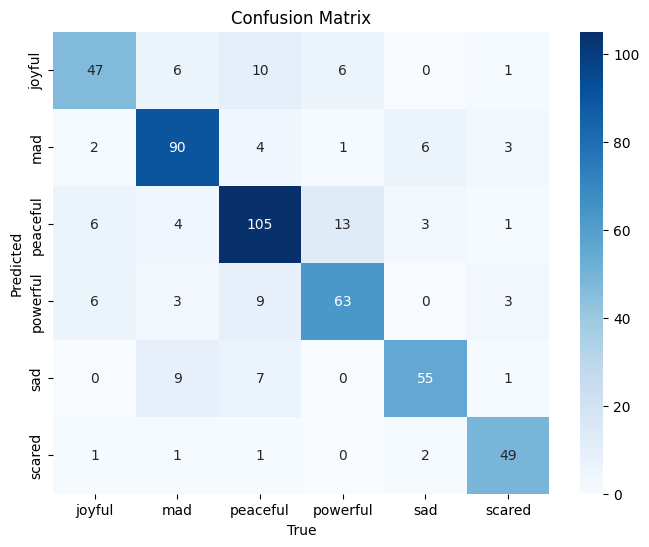

In [34]:
emotions = ['joyful', 'mad', 'peaceful', 'powerful', 'sad', 'scared']

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=emotions, yticklabels=emotions, cmap='Blues')
plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

In [28]:
def get_prediction(text):
    inputs = tokenizer(text, truncation=True, padding=True, max_length=max_length, return_tensors='pt').to("cuda")
    outputs = model(**inputs)
    probs = outputs[0].softmax(dim=1)
    return id2label[probs.argmax().item()]

In [51]:
get_prediction("Cumplire todas mis metas")

'powerful'